In [ ]:
import pandas as pd
import spacy
nlp = spacy.load('en_core_web_sm')
import time
import re
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/MSDA683/FinalProject/pak_app_bank_reviews.csv')

In [ ]:
df.head()

,Unnamed: 0,app,content,score,at
0,0,Al Habib,good,5,2025-07-11 10:24:50
1,1,Al Habib,Its useless i am trying to register my account...,1,2025-07-11 05:53:23
2,2,Al Habib,app is good but I have an issue now I'm living...,5,2025-07-10 23:28:19
3,3,Al Habib,bank is good coie sarvis,5,2025-07-10 21:49:23
4,4,Al Habib,There is so much wrong about this net banking ...,1,2025-07-10 18:01:09


In [ ]:
print(df.keys())

Index(['Unnamed: 0', 'app', 'content', 'score', 'at'], dtype='object')


In [ ]:
df.shape

(1967, 5)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1967 entries, 0 to 1966
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  1967 non-null   int64 
 1   app         1967 non-null   object
 2   content     1967 non-null   object
 3   score       1967 non-null   int64 
 4   at          1967 non-null   object
dtypes: int64(2), object(3)
memory usage: 77.0+ KB


In [ ]:
pakmobilebankrating_df = pd.DataFrame(df, columns=['app','content','score','at'])
print(pakmobilebankrating_df.shape)
pakmobilebankrating_df.head()

(1967, 4)


,app,content,score,at
0,Al Habib,good,5,2025-07-11 10:24:50
1,Al Habib,Its useless i am trying to register my account...,1,2025-07-11 05:53:23
2,Al Habib,app is good but I have an issue now I'm living...,5,2025-07-10 23:28:19
3,Al Habib,bank is good coie sarvis,5,2025-07-10 21:49:23
4,Al Habib,There is so much wrong about this net banking ...,1,2025-07-10 18:01:09


In [ ]:
print(pakmobilebankrating_df.keys())

Index(['app', 'content', 'score', 'at'], dtype='object')


In [ ]:
pakmobilebankrating_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1967 entries, 0 to 1966
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   app      1967 non-null   object
 1   content  1967 non-null   object
 2   score    1967 non-null   int64 
 3   at       1967 non-null   object
dtypes: int64(1), object(3)
memory usage: 61.6+ KB


In [ ]:
pakmobilebankrating_df.score.value_counts()

,count
score,
5,1118
1,624
4,82
3,75
2,68


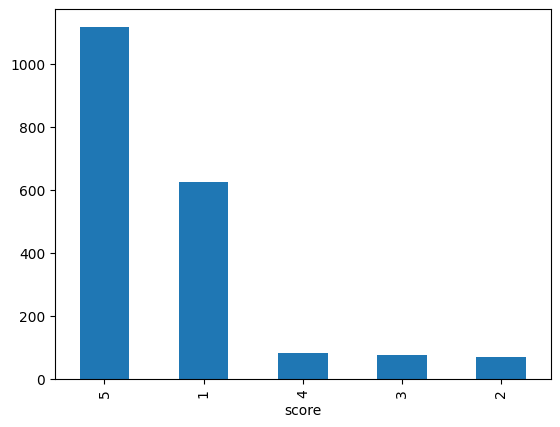

In [ ]:
pakmobilebankrating_df.score.value_counts().plot(kind='bar')
plt.savefig('/content/drive/MyDrive/MSDA683/FinalProject/PAKMOBILEbankratingcounts.jpg', bbox_inches='tight')

In [ ]:
def remove_urls(text):
    url_pattern = re.compile(r'https?://\S+|www\.\S+')
    return url_pattern.sub(r'', text)

pakmobilebankrating_df['content'] = pakmobilebankrating_df['content'].apply(lambda text: remove_urls(text))
pakmobilebankrating_df.head()

,app,content,score,at
0,Al Habib,good,5,2025-07-11 10:24:50
1,Al Habib,Its useless i am trying to register my account...,1,2025-07-11 05:53:23
2,Al Habib,app is good but I have an issue now I'm living...,5,2025-07-10 23:28:19
3,Al Habib,bank is good coie sarvis,5,2025-07-10 21:49:23
4,Al Habib,There is so much wrong about this net banking ...,1,2025-07-10 18:01:09


In [ ]:
import string
PUNCT_TO_REMOVE = string.punctuation
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', PUNCT_TO_REMOVE))

pakmobilebankrating_df['content'] = pakmobilebankrating_df['content'].apply(lambda text: remove_punctuation(text))
pakmobilebankrating_df.head()

,app,content,score,at
0,Al Habib,good,5,2025-07-11 10:24:50
1,Al Habib,Its useless i am trying to register my account...,1,2025-07-11 05:53:23
2,Al Habib,app is good but I have an issue now Im living ...,5,2025-07-10 23:28:19
3,Al Habib,bank is good coie sarvis,5,2025-07-10 21:49:23
4,Al Habib,There is so much wrong about this net banking ...,1,2025-07-10 18:01:09


In [ ]:
PAKMOBILEbankONEstardf = pakmobilebankrating_df[df['score'] == 1]


In [ ]:
PAKMOBILEbankONEstardf.head()

,app,content,score,at
1,Al Habib,Its useless i am trying to register my account...,1,2025-07-11 05:53:23
4,Al Habib,There is so much wrong about this net banking ...,1,2025-07-10 18:01:09
6,Al Habib,I cant tell what that was they dont have any i...,1,2025-07-10 12:29:28
7,Al Habib,My app is not working since 4 days i have a bu...,1,2025-07-10 11:13:18
8,Al Habib,Worst Experience app never work properly,1,2025-07-10 02:29:57


In [ ]:
start_time = time.perf_counter()
FiveStarAdj = []
FiveStarProds = []
for index, row in PAKMOBILEbankONEstardf.iterrows():
  doc = nlp(row['content'])
  for ent in doc.ents:
    if ent.label_ == 'PRODUCT':
      FiveStarProds.append(str(ent).lower().capitalize())
  for token in doc:
    if token.pos_ == 'ADJ':
      FiveStarAdj.append(str(token).capitalize())
end_time = time.perf_counter()
print(f"Elapsed time: {end_time - start_time} seconds")
print(f"Found {len(FiveStarProds)} brands mentioned in {len(PAKMOBILEbankONEstardf)} reviews" )

Elapsed time: 7.543922908000013 seconds
Found 18 brands mentioned in 624 reviews


In [ ]:
 sorted_PAKMOBILEbank_Prodlist = sorted(FiveStarProds, key=str)
 top_PAKMOBILEbank_Prodlist = pd.DataFrame(Counter(sorted_PAKMOBILEbank_Prodlist).most_common(20), columns=['Product','Count'])
 print(top_PAKMOBILEbank_Prodlist)

        Product  Count
0           App      3
1           Hbl      2
2      Jazzcash      2
3             😡      2
4   Application      1
5        Online      1
6      Password      1
7    Pkr 150000      1
8    Samsung c7      1
9      Terrible      1
10         Uiux      1
11       خامیاں      1
12          کام      1


In [ ]:
PAKMOBILEfinal_PRODUCTlist = top_PAKMOBILEbank_Prodlist

In [ ]:
PAKMOBILEfinal_PRODUCTlist = PAKMOBILEfinal_PRODUCTlist.drop(index=11)

In [ ]:
print(PAKMOBILEfinal_PRODUCTlist)

        Product  Count
0           App      3
1           Hbl      2
2      Jazzcash      2
3             😡      2
4   Application      1
5        Online      1
6      Password      1
7    Pkr 150000      1
8    Samsung c7      1
9      Terrible      1
10         Uiux      1


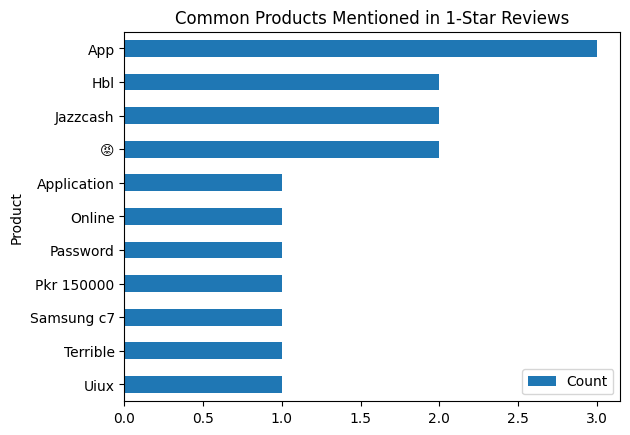

In [ ]:
plot = PAKMOBILEfinal_PRODUCTlist.plot.barh(x='Product', y='Count',
                            title='Common Products Mentioned in 1-Star Reviews').invert_yaxis()
plt.savefig('/content/drive/MyDrive/MSDA683/FinalProject/PAKMOBILEcommonproducts1starbanks.jpg', bbox_inches='tight')

In [ ]:
sorted_PAKMOBILEbank_Adjlist = sorted(FiveStarAdj, key=str)
top_PAKMOBILEbank_Adjlist = pd.DataFrame(Counter(sorted_PAKMOBILEbank_Adjlist).most_common(20), columns=['Adjective','Count'])
print(top_PAKMOBILEbank_Adjlist)

       Adjective  Count
0          Worst     62
1            Bad     61
2           Poor     34
3         Unable     33
4           Slow     32
5       Pathetic     31
6            New     27
7        Useless     27
8           Good     26
9           Many     26
10          Same     26
11         Other     20
12     Biometric     17
13        Mobile     17
14         Third     17
15          Last     16
16          Able     15
17     Available     15
18   Frustrating     15
19  Disappointed     13


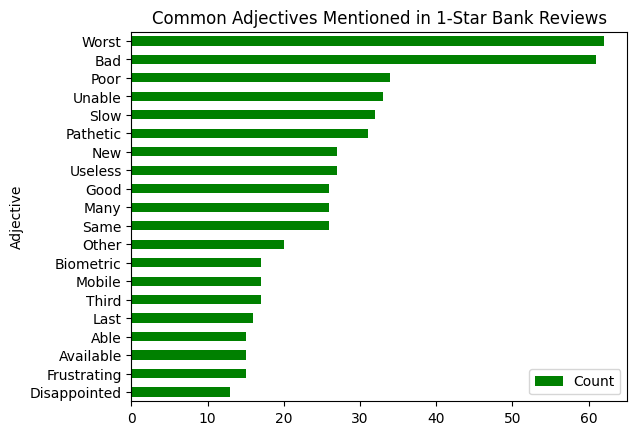

In [ ]:
plot = top_PAKMOBILEbank_Adjlist.plot.barh(x='Adjective', y='Count', color = 'green',
                            title='Common Adjectives Mentioned in 1-Star Bank Reviews').invert_yaxis()
plt.savefig('/content/drive/MyDrive/MSDA683/FinalProject/PAKMOBILE1starBANKADJ.jpg', bbox_inches='tight')

In [ ]:
start_time = time.perf_counter()
PAKMOBILEbankFiveStarAdjOne = []
for index, row in PAKMOBILEbankONEstardf.iterrows():
  doc = nlp(row['content'])
  for ent in doc.ents:
    if ent.label_ == 'PRODUCT' and str(ent).lower() == "app":
      for token in doc:
        if token.pos_ == 'ADJ':
          PAKMOBILEbankONEstarAdjOne.append(str(token).capitalize())
end_time = time.perf_counter()
print(f"Elapsed time: {end_time - start_time} seconds")
print(PAKMOBILEbankONEstarAdjOne)

Elapsed time: 6.566030914000066 seconds
['New', 'Slow', 'Old', 'Faster', 'Public', 'Pathetic', 'Able', 'Public', 'Pathetic']


In [ ]:
sorted_PAKMOBILEbank_AdjlistOne = sorted(PAKMOBILEbankONEstarAdjOne, key=str)
top_PAKMOBILEbank_AdjlistOne = pd.DataFrame(Counter(sorted_PAKMOBILEbank_AdjlistOne).most_common(20), columns=['Adjective','Count'])
print(top_PAKMOBILEbank_AdjlistOne)

  Adjective  Count
0  Pathetic      2
1    Public      2
2      Able      1
3    Faster      1
4       New      1
5       Old      1
6      Slow      1


In [ ]:
start_time = time.perf_counter()
PAKmobile_related_nouns = []

for index, row in PAKMOBILEbankONEstardf.iterrows():
    doc = nlp(row['content'])
    mobile_token_indices = [token.i for token in doc if token.text.lower() == "mobile"]

    for mobile_index in mobile_token_indices:
        for token in doc[max(0, mobile_index - 5) : min(len(doc), mobile_index + 6)]:
            if token.pos_ == 'NOUN':
                PAKmobile_related_nouns.append(str(token).capitalize())

end_time = time.perf_counter()
print(f"Elapsed time: {end_time - start_time} seconds")
print(f"Found {len(PAKmobile_related_nouns)} mobile-related nouns in {len(PAKMOBILEbankONEstardf)} reviews" )

Elapsed time: 5.904719127999897 seconds
Found 98 mobile-related nouns in 624 reviews


In [ ]:
sorted_PAKmobile_nouns = sorted(PAKmobile_related_nouns, key=str)
top_PAKmobile_nouns = pd.DataFrame(Counter(sorted_PAKmobile_nouns).most_common(20), columns=['Noun','Count'])
print(top_PAKmobile_nouns)

            Noun  Count
0            App     14
1         Mobile     12
2        Banking      8
3         Number      3
4          Phone      3
5    Application      2
6        Balance      2
7           Bank      2
8     Experience      2
9         Losses      2
10       Package      2
11       Version      2
12           Aap      1
13       Account      1
14        Action      1
15        Amount      1
16       Android      1
17     Appalways      1
18  Applications      1
19         Banks      1


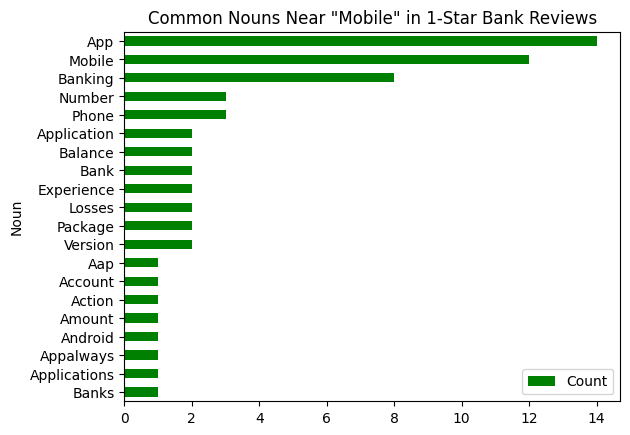

In [ ]:
if not top_PAKmobile_nouns.empty:
    plot = top_PAKmobile_nouns.plot.barh(x='Noun', y='Count', color = 'green',
                                title='Common Nouns Near "Mobile" in 1-Star Bank Reviews').invert_yaxis()
    plt.savefig('/content/drive/MyDrive/MSDA683/FinalProject/PAKmobile_related_nouns_1star.jpg', bbox_inches='tight')
else:
    print("PAKmobile-related nouns")

In [ ]:
start_time = time.perf_counter()
PAKMOBILEapp_related_adjectives = []

for index, row in PAKMOBILEbankONEstardf.iterrows():
    doc = nlp(row['content'])
    app_token_indices = [token.i for token in doc if token.text.lower() == "app"]

    for app_index in app_token_indices:
        # Look for adjectives in the surrounding 5 tokens (adjust window size as needed)
        for token in doc[max(0, app_index - 5) : min(len(doc), app_index + 6)]:
            if token.pos_ == 'ADJ':
                PAKMOBILEapp_related_adjectives.append(str(token).capitalize())

end_time = time.perf_counter()
print(f"Elapsed time: {end_time - start_time} seconds")
print(f"Found {len(PAKMOBILEapp_related_adjectives)} app-related adjectives in {len(PAKMOBILEbankONEstardf)} reviews" )

Elapsed time: 9.064807847999873 seconds
Found 346 app-related adjectives in 624 reviews


In [ ]:
sorted_PAKMOBILEapp_adjectives = sorted(PAKMOBILEapp_related_adjectives, key=str)
top_PAKMOBILEapp_adjectives = pd.DataFrame(Counter(sorted_PAKMOBILEapp_adjectives).most_common(20), columns=['Adjective','Count'])
print(top_PAKMOBILEapp_adjectives)

      Adjective  Count
0         Worst     38
1           Bad     21
2       Useless     14
3      Pathetic     13
4        Mobile     11
5          Slow     11
6          Poor     10
7          Many      9
8      Terrible      9
9        Better      8
10         Good      8
11          Old      8
12       Stupid      7
13       Unable      7
14  Frustrating      6
15          New      6
16         Able      5
17         Open      5
18       Public      5
19        Third      5


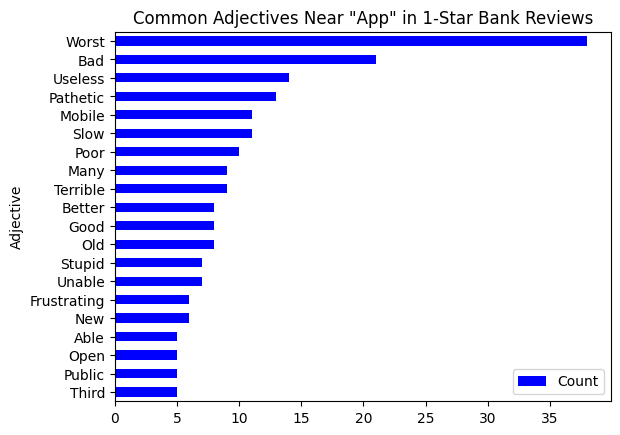

In [ ]:
if not top_PAKMOBILEapp_adjectives.empty:
    plot = top_PAKMOBILEapp_adjectives.plot.barh(x='Adjective', y='Count', color = 'blue',
                                title='Common Adjectives Near "App" in 1-Star Bank Reviews').invert_yaxis()
    plt.savefig('/content/drive/MyDrive/MSDA683/FinalProject/PAKMOBILEapp_related_adjectives_1star.jpg', bbox_inches='tight')

                                             content sentiment
0                                               good  positive
1  Its useless i am trying to register my account...  negative
2  app is good but I have an issue now Im living ...  positive
3                           bank is good coie sarvis  positive
4  There is so much wrong about this net banking ...  negative
sentiment
positive    1254
negative     418
neutral      295
Name: count, dtype: int64


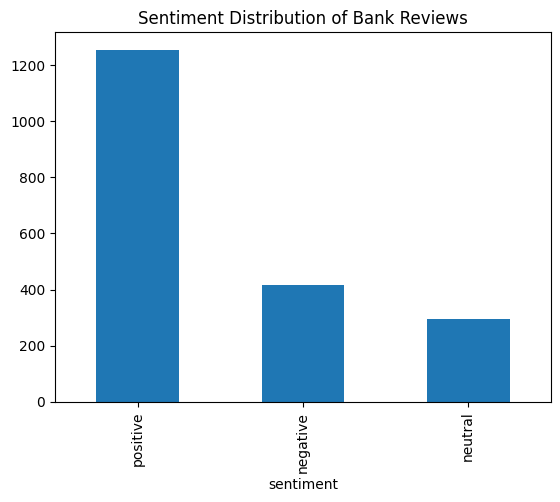

In [ ]:
!pip install textblob

from textblob import TextBlob

def get_sentiment(text):
    '''
    Utility function to classify sentiment of passed tweet
    using textblob's sentiment method
    '''
    # create TextBlob object of passed tweet text
    analysis = TextBlob(text)
    # set sentiment
    if analysis.sentiment.polarity > 0:
        return 'positive'
    elif analysis.sentiment.polarity == 0:
        return 'neutral'
    else:
        return 'negative'

pakmobilebankrating_df['sentiment'] = pakmobilebankrating_df['content'].apply(get_sentiment)

print(pakmobilebankrating_df[['content', 'sentiment']].head())

print(pakmobilebankrating_df['sentiment'].value_counts())

pakmobilebankrating_df['sentiment'].value_counts().plot(kind='bar', title='Sentiment Distribution of Bank Reviews')
plt.savefig('/content/drive/MyDrive/MSDA683/FinalProject/pakmobilesentiment_distribution.jpg', bbox_inches='tight')
plt.show()


Sentiment analysis for reviews mentioning 'mobile' or 'app':
                                             content sentiment
2  app is good but I have an issue now Im living ...  positive
4  There is so much wrong about this net banking ...  negative
5                          good app and fast service  positive
6  I cant tell what that was they dont have any i...  positive
7  My app is not working since 4 days i have a bu...  negative

Sentiment distribution for reviews mentioning 'mobile' or 'app':
sentiment
positive    455
negative    258
neutral     115
Name: count, dtype: int64


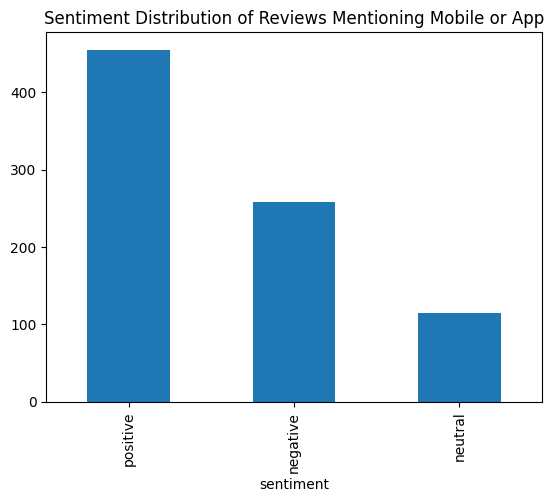

In [ ]:
# prompt: create sentiment analysis of reviews that mention mobile or app

# Filter reviews that mention 'mobile' or 'app'
PAKmobile_app_reviews_df = pakmobilebankrating_df[
    pakmobilebankrating_df['content'].str.contains('mobile|app', case=False, na=False)
].copy()

# Apply sentiment analysis to the filtered reviews
PAKmobile_app_reviews_df['sentiment'] = PAKmobile_app_reviews_df['content'].apply(get_sentiment)

print("\nSentiment analysis for reviews mentioning 'mobile' or 'app':")
print(PAKmobile_app_reviews_df[['content', 'sentiment']].head())

print("\nSentiment distribution for reviews mentioning 'mobile' or 'app':")
print(PAKmobile_app_reviews_df['sentiment'].value_counts())

# Plot the sentiment distribution for these filtered reviews
PAKmobile_app_reviews_df['sentiment'].value_counts().plot(
    kind='bar', title='Sentiment Distribution of Reviews Mentioning Mobile or App'
)
plt.savefig('/content/drive/MyDrive/MSDA683/FinalProject/PAKmobile_app_sentiment_distribution.jpg', bbox_inches='tight')
plt.show()

Elapsed time: 4.229979285999889 seconds
Found 949 adjectives in 418 negative reviews

Top 20 Adjectives in Negative Sentiment Reviews:
       Adjective  Count
0            Bad     68
1          Worst     62
2         Unable     43
3           Slow     40
4           Poor     35
5       Pathetic     34
6          Other     24
7        Useless     24
8           Same     22
9           Good     17
10        Mobile     17
11          Last     16
12  Disappointed     15
13   Frustrating     15
14          Able     13
15     Biometric     12
16           New     12
17         Wrong     12
18      Multiple     11
19          Many     10


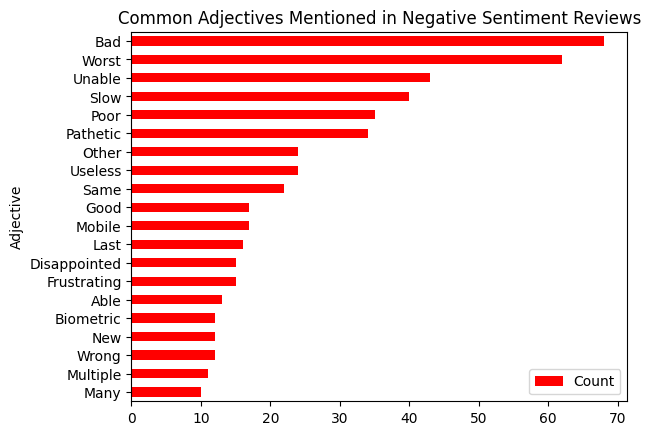

In [ ]:
# prompt: top 20 adjectives used in negative sentiment reviews along with their counts

# Filter for negative sentiment reviews
PAKMOBILEnegative_reviews_df = pakmobilebankrating_df[pakmobilebankrating_df['sentiment'] == 'negative'].copy()

# Extract adjectives from negative reviews
start_time = time.perf_counter()
PAKMOBILEnegative_adjectives = []
for index, row in PAKMOBILEnegative_reviews_df.iterrows():
    doc = nlp(row['content'])
    for token in doc:
        if token.pos_ == 'ADJ':
            PAKMOBILEnegative_adjectives.append(str(token).capitalize())

end_time = time.perf_counter()
print(f"Elapsed time: {end_time - start_time} seconds")
print(f"Found {len(PAKMOBILEnegative_adjectives)} adjectives in {len(PAKMOBILEnegative_reviews_df)} negative reviews" )

# Count the occurrences of each adjective and get the top 20
sorted_PAKMOBILEnegative_adjectives = sorted(PAKMOBILEnegative_adjectives, key=str)
top_PAKMOBILEnegative_adjectives = pd.DataFrame(
    Counter(sorted_PAKMOBILEnegative_adjectives).most_common(20),
    columns=['Adjective','Count']
)

print("\nTop 20 Adjectives in Negative Sentiment Reviews:")
print(top_PAKMOBILEnegative_adjectives)

# Plot the top 20 negative adjectives
if not top_PAKMOBILEnegative_adjectives.empty:
    plot = top_PAKMOBILEnegative_adjectives.plot.barh(
        x='Adjective',
        y='Count',
        color = 'red',
        title='Common Adjectives Mentioned in Negative Sentiment Reviews'
    ).invert_yaxis()
    plt.savefig('/content/drive/MyDrive/MSDA683/FinalProject/PAKMOBILEnegative_adjectivesinsentimentanalysis.jpg', bbox_inches='tight')
    plt.show()
else:
    print("No adjectives found in negative reviews.")

In [ ]:
PAKMOBILEnegative_mobile_app_reviews_df = pakmobilebankrating_df[pakmobilebankrating_df['sentiment'] == 'negative'].copy()

print("\nNegative Sentiment Reviews mentioning 'mobile' or 'app':")
PAKMOBILEnegative_mobile_app_reviews_df



Negative Sentiment Reviews mentioning 'mobile' or 'app':


,app,content,score,at,sentiment
1,Al Habib,Its useless i am trying to register my account...,1,2025-07-11 05:53:23,negative
4,Al Habib,There is so much wrong about this net banking ...,1,2025-07-10 18:01:09,negative
7,Al Habib,My app is not working since 4 days i have a bu...,1,2025-07-10 11:13:18,negative
8,Al Habib,Worst Experience app never work properly,1,2025-07-10 02:29:57,negative
9,Al Habib,stupid not working since 2 days,2,2025-07-09 23:28:20,negative
...,...,...,...,...,...
1918,UBL Digital,I used this app for so long but today its not ...,1,2025-06-27 19:02:50,negative
1933,UBL Digital,app shut down whenever I try to open list of a...,3,2025-06-27 12:34:10,negative
1935,UBL Digital,so complicated when you sign in to multiple de...,1,2025-06-27 11:20:06,negative
1936,UBL Digital,I’ve been trying to reset my password for mont...,1,2025-06-27 11:12:06,negative


In [ ]:
PAKMOBILEnegative_mobile_app_reviews_df.to_csv('/content/drive/MyDrive/MSDA683/FinalProject/PAKMOBILEnegative_mobile_app_reviews.csv', index=False)
print("\nSaved negative mobile/app reviews to 'negative_mobile_app_reviews.csv'")


Saved negative mobile/app reviews to 'negative_mobile_app_reviews.csv'
